Experiment 5: Advanced Convolutional Neural Networks

Aim:To implement an advanced Convolutional Neural Network (CNN) using TensorFlow and Keras with Dropout layers for improved image classification performance.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 368s 2us/step


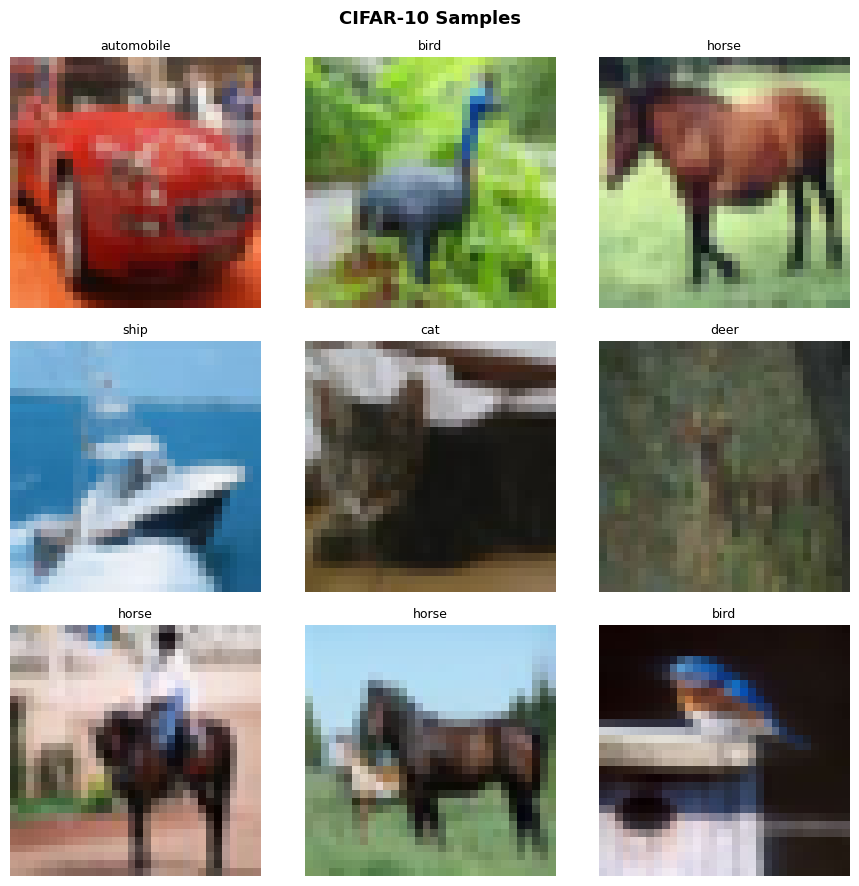

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,070,794 (4.08 MB)

 Trainable params: 1,070,794 (4.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 26s 311ms/step - accuracy: 0.2135 - loss: 2.0917 - val_accuracy: 0.3657 - val_loss: 1.8150
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 288ms/step - accuracy: 0.3638 - loss: 1.7413 - val_accuracy: 0.4310 - val_loss: 1.6275
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 41s 293ms/step - accuracy: 0.4195 - loss: 1.5871 - val_accuracy: 0.4743 - val_loss: 1.4821
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 23s 290ms/step - accuracy: 0.4665 - loss: 1.4806 - val_accuracy: 0.5240 - val_loss: 1.3597
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 23s 285ms/step - accuracy: 0.4952 - loss: 1.3955 - val_accuracy: 0.5388 - val_loss: 1.3248

Test Loss     : 1.3248
Test Accuracy : 0.5388


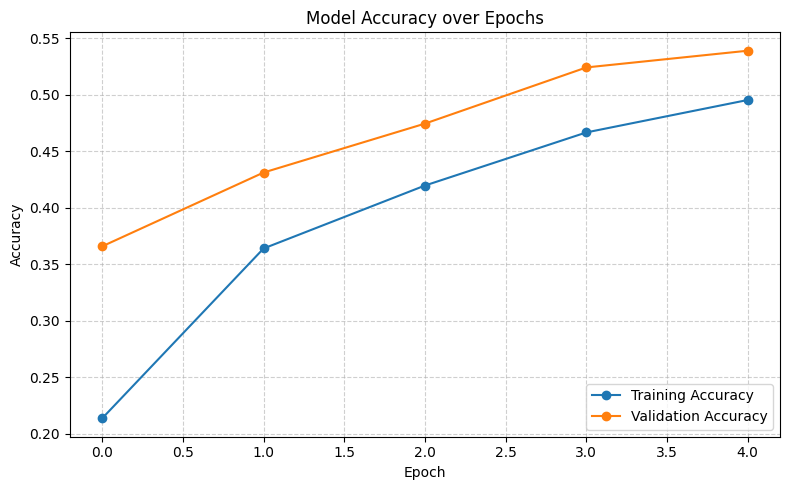

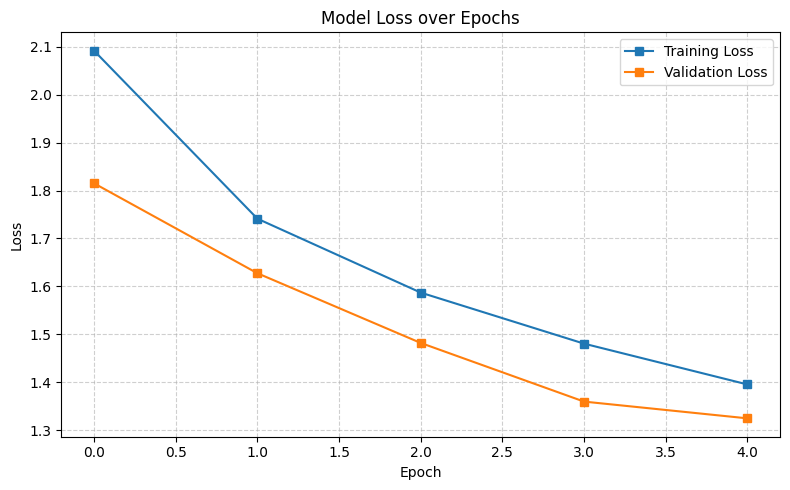

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# Load CIFAR-10 Dataset
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

# Normalize Dataset
X_train = X_train / 255.0
X_test = X_test / 255.0

# Class Names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Display Sample Images
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
fig.suptitle('CIFAR-10 Samples', fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i + 5])
    ax.set_title(class_names[y_train[i + 5][0]], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Use only a subset for faster training        ← KEY CHANGE
X_train_fast = X_train[:10000]
y_train_fast = y_train[:10000]

# Build CNN Model (Lighter)
model = models.Sequential([

    # First Convolution Block
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),                 # Removed second Conv2D in block
    layers.Dropout(0.25),

    # Second Convolution Block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),                 # Removed second Conv2D in block
    layers.Dropout(0.25),

    # Flatten Layer
    layers.Flatten(),

    # Fully Connected Layers
    layers.Dense(256, activation='relu'),        # Reduced from 512
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Model Summary
model.summary()

# Compile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = model.fit(
    X_train_fast,                               # Subset of training data
    y_train_fast,
    epochs=5,                                   # Reduced from 15
    batch_size=128,                             # Increased from 64
    validation_data=(X_test, y_test),
    verbose=1
)

# Evaluate Model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

# Plot Accuracy Graph
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'],     label='Training Accuracy',   marker='o', linewidth=1.5)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o', linewidth=1.5)

plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Plot Loss Graph
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'],     label='Training Loss',   marker='s', linewidth=1.5)
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s', linewidth=1.5)

plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Conclusion: Successfully implemented an advanced CNN model using multiple convolution layers and dropout regularization for image classification on the CIFAR-10 dataset.